# Asymmetric Feedback Model: Fitting to Experimental Data


## Mathematical Derivation

### Proportional Feedback

The standard proportional feedback model regulates synthesis rate based on total protein concentration:

$$\frac{dA_n}{dt} = k_s - \delta_A \cdot A_n$$

$$\frac{dB_n}{dt} = k_s - \delta_B \cdot B_n$$

where the synthesis rate follows Michaelis-Menten-like feedback:

$$k_s = k_{s,\max} \cdot \frac{S}{S + A_n + B_n}$$

Here:
- $A_n$, $B_n$ are nuclear concentrations of RFP and GFP
- $k_{s,\max}$ is the maximum synthesis rate
- $S$ is the feedback sensitivity parameter (half-saturation constant)
- $\delta_A$, $\delta_B$ are degradation rates

### Asymmetric (One-Directional) Feedback

Because synthesis does not change when nuclear levels are increased through perturbation of
POLR2A decay pathway (ARMC5), we know that feedback should only respond to reduced and not
increased levels. We therefore modify the feedback to respond **only when total protein
drops below a reference level** $\text{Total}_{\text{ref}}$:

$$k_s = \begin{cases}
k_{s,\max} \cdot \frac{S}{S + A_n + B_n} & \text{if } A_n + B_n < \text{Total}_{\text{ref}} \\
k_{s,\max} \cdot \frac{S}{S + \text{Total}_{\text{ref}}} & \text{if } A_n + B_n \geq \text{Total}_{\text{ref}}
\end{cases}$$

- **Below threshold**: Active feedback compensates for depletion (synthesis increases)
- **Above threshold**: Feedback inactive (synthesis remains at minimum)

### Differential Degradation

To reproduce the observed higher steady-state level of RFP (A) compared to GFP (B), we allow different base degradation rates. Using the same symbols as the competition model notebook ($\delta_A \equiv \delta_n^A$, $\delta_B \equiv \delta_n^B$):

- $\delta_n^A$ (measured, bleach chase)
- $\delta_n^B = f_B \cdot \delta_n^A$, where $f_B$ is the RFP/GFP normalization ratio
- $\delta_n^B \to \delta_n^B + \delta_n^B(\mathrm{degron})$ when auxin is added

Note that the degron acts only on the nuclear removal rate here because this model has no cytoplasmic compartment.


### Parameters

**Free parameters (3):**
- $k_{s,\max}$ (maximum synthesis rate)
- $S$ (feedback sensitivity)
- $\delta_n^B(\mathrm{degron})$ (auxin degradation increment, added to $\delta_n^B$)

**Fixed parameters (from experimental measurements):**
- $\text{Total}_{\text{ref}}$ (reference threshold, set to steady-state total)
- $\delta_n^A$ (nuclear removal rate for RFP from bleach chase experiments, VEH treatment)
- $\delta_n^B = f_B \cdot \delta_n^A$ (calculated from steady-state ratio)

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# Data directory (all input CSVs)
DATA_DIR = Path("../data")

# Random seed for reproducible fitting
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Import our model functions
from models import integrate_feedback_to_steady_state, simulate_feedback_trajectory
from utils import (
    save_parameters,
    load_experimental_data,
    calculate_time_averages,
    plot_data_preview,
)

# Plotting style
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## Load Experimental Data

Loaded data for: ['VEH_AUX', 'AUX_VEH']


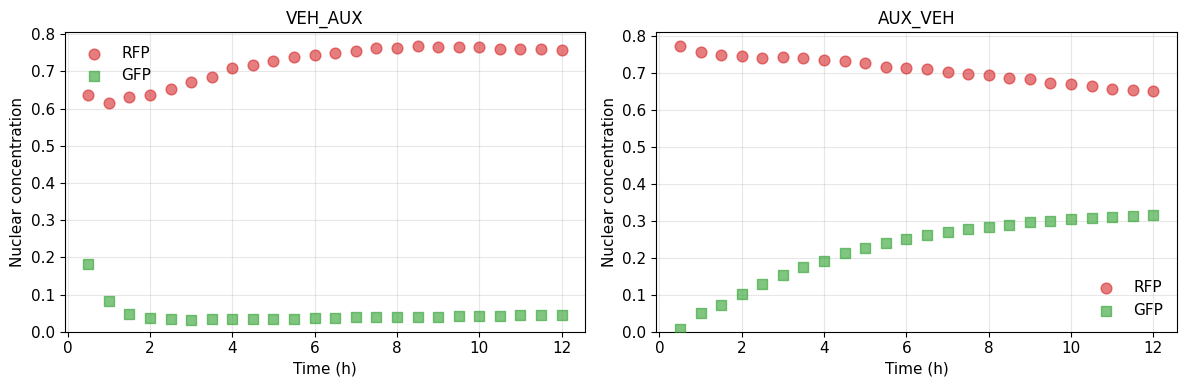

In [126]:
# Data normalization factors
RFP_NORMALIZATION = 0.5994
GFP_NORMALIZATION = 0.4153

# Load and normalize data
data_path = DATA_DIR / "mACmCh_LiveCellWashout_Values_ByExperiment.csv"
data = load_experimental_data(
    data_path, {"RFP": RFP_NORMALIZATION, "GFP": GFP_NORMALIZATION}
)

# Calculate time-averaged data
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded data for: {list(data_averaged.keys())}")

# Preview the data
plot_data_preview(data_averaged, fit_conditions)

## Fixed Parameters

In [127]:
# Reference level (steady-state total)
TOTAL_REF = RFP_NORMALIZATION + GFP_NORMALIZATION

# Load bleach chase data to get removal rate
bleach_chase_path = DATA_DIR / "mACmCh_BleachChase_ByExperiment.csv"
bleach_chase_df = pd.read_csv(bleach_chase_path, index_col=0)

# Bleach chase was performed on mCherry-POLR2A (protein A) ONLY. The removal rate
# is unchanged by 5-Ph-IAA (see the bar plot in previous notebook), so VEH and AUX
# are pooled into a single estimate of delta_n^A.
# Note this rate incorporates dilution due to cell growth.
DELTA_N_A = bleach_chase_df["RemovalRate_perhr"].mean()

# Other fixed degradation rates
DELTA_N_B_FACTOR = RFP_NORMALIZATION / GFP_NORMALIZATION  # From steady-state ratio
DELTA_N_B = DELTA_N_B_FACTOR * DELTA_N_A  # Basal nuclear removal rate for B

# Loss weighting (applied to VEH_AUX only; all other points have weight 1)
RFP_WEIGHT = 50.0  # RFP points at t > 3 h (buffering plateau)
EARLY_RFP_WEIGHT = 200.0  # RFP points at 1 h < t <= 3 h (recovery shape)
EARLY_GFP_WEIGHT = 25.0  # GFP points at t <= 3 h (decay that constrains the degron)

print("Fixed parameters:")
print(f"  Total_ref = {TOTAL_REF:.4f}")
print(f"  δ_n^A = {DELTA_N_A:.4f} hr⁻¹ (from bleach chase data, n={len(veh_data)})")
print(f"  δ_n^B = {DELTA_N_B:.4f} hr⁻¹ (t½ = {np.log(2)/DELTA_N_B:.1f}h)")

Fixed parameters:
  Total_ref = 1.0147
  δ_n^A = 0.1356 hr⁻¹ (from bleach chase data, n=3)
  δ_n^B = 0.1958 hr⁻¹ (t½ = 3.5h)


## Define Fitting Objective

In [128]:
def objective_function(theta, data_averaged, return_predictions=False):
    """
    Objective function for parameter fitting.

    Parameters
    ----------
    theta : array-like
        [k_s_max, S, delta_n_B_degron]
    data_averaged : dict
        Experimental data
    return_predictions : bool
        If True, return (loss, predictions)
    """
    k_s_max, S, delta_n_B_degron = theta

    if k_s_max <= 0 or S <= 0 or delta_n_B_degron <= 0:
        return 1e10 if not return_predictions else (1e10, None)

    # Calculate steady states
    try:
        ss_control = integrate_feedback_to_steady_state(
            k_s_max, S, TOTAL_REF, DELTA_N_A, DELTA_N_B
        )
        ss_perturbed = integrate_feedback_to_steady_state(
            k_s_max, S, TOTAL_REF, DELTA_N_A, DELTA_N_B + delta_n_B_degron
        )
    except:
        return 1e10 if not return_predictions else (1e10, None)

    # Simulate conditions
    conditions = {
        "VEH_AUX": (
            ss_control,
            DELTA_N_B + delta_n_B_degron,
        ),
        "AUX_VEH": (ss_perturbed, DELTA_N_B),
    }

    loss = 0.0
    predictions = {}

    for code, (y0, delta_B) in conditions.items():
        if code not in data_averaged:
            continue

        data = data_averaged[code]
        t_max = data["time"].max()

        try:
            traj, times = simulate_feedback_trajectory(
                k_s_max, S, TOTAL_REF, DELTA_N_A, delta_B, t_max, y0, n_points=100
            )
        except:
            return 1e10 if not return_predictions else (1e10, None)

        # Interpolate to data time points
        A_n_interp = np.interp(data["time"], times, traj[0])
        B_n_interp = np.interp(data["time"], times, traj[1])

        # Per-point weights (VEH_AUX only): emphasise the early GFP decay that
        # constrains the degron, and the RFP recovery shape
        gfp_weights = np.ones(len(data))
        rfp_weights = np.ones(len(data))
        if code == "VEH_AUX":
            gfp_weights[data["time"].to_numpy() <= 3.0] = EARLY_GFP_WEIGHT
            rfp_weights[data["time"].to_numpy() <= 6.0] = EARLY_RFP_WEIGHT
            rfp_weights[data["time"].to_numpy() <= 1.0] = 1.0
            rfp_weights[data["time"].to_numpy() > 3.0] = RFP_WEIGHT

        rfp_error = np.sum(rfp_weights * (A_n_interp - data["rfp"]) ** 2)
        gfp_error = np.sum(gfp_weights * (B_n_interp - data["gfp"]) ** 2)

        loss += rfp_error + gfp_error

        if return_predictions:
            predictions[code] = {
                "time": times,
                "A_n": traj[0],
                "B_n": traj[1],
                "A_n_interp": A_n_interp,
                "B_n_interp": B_n_interp,
            }

    if return_predictions:
        return loss, predictions
    return loss

## Run Optimization

In [129]:
# Initial guess and bounds
theta0 = [0.3, 0.5, 1.8]  # [k_s_max, S, delta_n_B_degron]
bounds = [(0.01, 1.0), (0.01, 2.0), (0.1, 5.0)]

print("Running optimization...")
result = minimize(
    objective_function, theta0, args=(data_averaged,), method="L-BFGS-B", bounds=bounds
)

best_params_array = result.x
best_loss = result.fun

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"Final loss: {best_loss:.4e}")
print(f"\nBest-fit parameters:")
print(f"  k_s_max = {best_params_array[0]:.4f} hr⁻¹")
print(f"  S       = {best_params_array[1]:.4f}")
print(f"  delta_n_B_degron = {best_params_array[2]:.4f} hr⁻¹")

Running optimization...

OPTIMIZATION COMPLETE
Final loss: 7.5398e-01

Best-fit parameters:
  k_s_max = 1.0000 hr⁻¹
  S       = 0.0916
  delta_n_B_degron = 2.3100 hr⁻¹


## Save Parameters

In [130]:
# Package parameters for saving
best_params = {
    "k_s_max": best_params_array[0],
    "S": best_params_array[1],
    "Total_ref": TOTAL_REF,
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
    "delta_n_B_degron": best_params_array[2],
}

# Save to JSON
output_path = Path("fitted_parameters/feedback_params.json")
save_parameters(best_params, output_path)
print(f"\nSaved parameters to: {output_path.resolve()}")


Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/feedback_params.json


## Visualise Fits

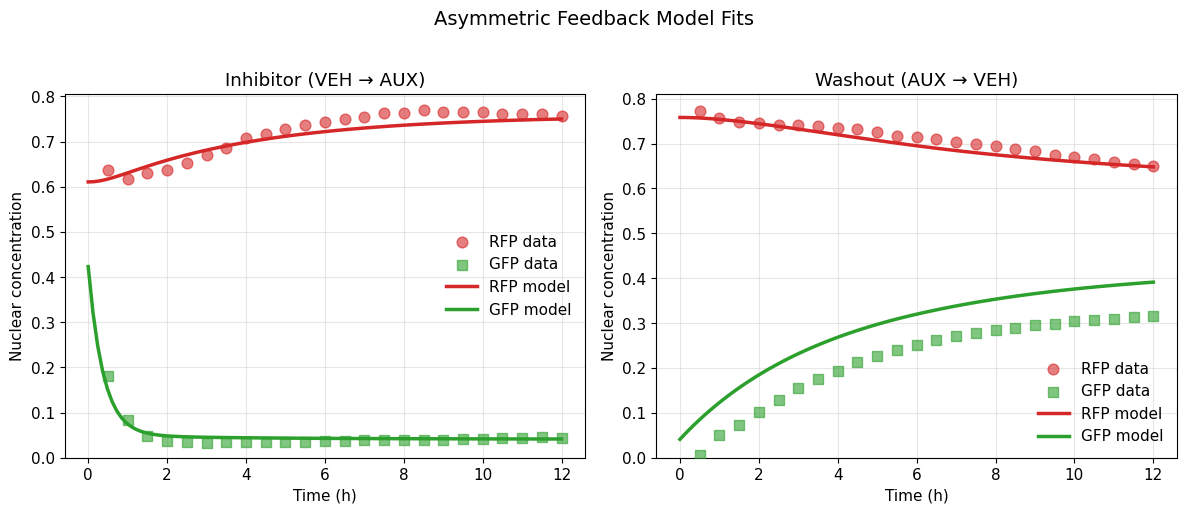

In [131]:
# Get predictions with best parameters
_, predictions = objective_function(
    best_params_array, data_averaged, return_predictions=True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    data = data_averaged[code]
    pred = predictions[code]

    # Plot data
    ax.scatter(
        data["time"],
        data["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        label="RFP data",
        zorder=3,
    )
    ax.scatter(
        data["time"],
        data["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        label="GFP data",
        zorder=3,
    )

    # Plot model
    ax.plot(
        pred["time"], pred["A_n"], color=colors["rfp"], linewidth=2.5, label="RFP model"
    )
    ax.plot(
        pred["time"], pred["B_n"], color=colors["gfp"], linewidth=2.5, label="GFP model"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Nuclear concentration")
    ax.set_title(titles[code])
    ax.legend(frameon=False)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

fig.suptitle("Asymmetric Feedback Model Fits", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/feedback_model_fits.pdf", bbox_inches="tight")
plt.show()